In [1]:
import pandas as pd
df=pd.read_csv("olist_no_missing_dataset.csv") #for interpretation of clustering results
cluster_df = pd.read_csv("olist_cleaned_dataset.csv")

In [2]:
cluster_df=cluster_df.drop(columns=['city','state','customer_unique_id','most_bought_category','aov_range','avg_item_price_range','least_bought_category','least_used_payment'])

In [19]:
pd.set_option('display.max_columns',None)

In [3]:
#feature selection
#from correlation heatmap total_spent, avg_order_value, avg_item_price_per_order are highly correlated
cluster_df=cluster_df.drop(columns=['avg_order_value','avg_item_price_per_order'])

In [5]:
cluster_df

,num_orders,total_spent,avg_items_per_order,avg_review,avg_installments,latitude,longitude,recency_days,num_product_categories,most_used_payment_boleto,...,cat_pca_1,cat_pca_2,cat_pca_3,cat_pca_4,cat_pca_5,cat_pca_6,cat_pca_7,cat_pca_8,cat_pca_9,cat_pca_10
0,-0.159829,-0.015717,-0.172165,0.663285,1.898826,-0.383518,-0.158997,-0.790661,-0.053651,0.0,...,-0.637624,-0.327896,-0.102259,0.059743,-0.020116,0.189493,-0.198020,0.051733,0.008437,0.073418
1,-0.159829,-0.574829,-0.172165,-0.120408,-0.707834,-0.422565,-0.148502,-0.751176,-0.053651,0.0,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
2,-0.159829,-0.322473,-0.172165,-0.904101,1.898826,-1.133248,-0.604148,1.881163,-0.053651,0.0,...,-0.018761,-0.047356,-0.095521,0.369686,0.141457,-0.068647,0.166585,0.079676,0.160974,-0.034467
3,-0.159829,-0.539117,-0.172165,-0.120408,0.409306,3.546167,-0.567054,0.499185,-0.053651,0.0,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
4,-0.159829,0.236639,-0.172165,0.663285,1.154066,-0.413009,-0.316877,0.328083,-0.053651,0.0,...,0.146240,0.166802,-0.219602,0.525551,-0.100747,-0.413076,-0.126003,0.418943,-0.255063,0.020480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93353,-0.159829,7.238135,4.284975,0.663285,2.643586,2.288431,2.375666,1.282306,-0.053651,0.0,...,-0.209777,0.588827,0.471880,-0.118288,-0.149629,0.046770,-0.092128,0.047734,-0.035847,0.026227
93354,-0.159829,-0.343176,-0.172165,-0.120408,-0.707834,1.600739,1.783962,0.045106,-0.053651,0.0,...,0.135171,0.216795,0.033849,0.272789,0.337885,-0.103309,-0.304037,-0.196557,0.221637,0.099556
93355,-0.159829,-0.217199,-0.172165,0.663285,-0.707834,1.669036,-2.301202,2.164139,-0.053651,0.0,...,0.294390,0.044495,-0.061878,0.295636,-0.110412,0.192365,-0.224561,-0.345526,0.011077,-0.522030
93356,-0.159829,-0.090769,-0.172165,0.663285,0.781686,0.011389,1.114120,-0.770919,-0.053651,0.0,...,0.158176,0.013189,-0.062204,-0.312452,0.603046,0.140091,-0.017123,0.195443,-0.321531,-0.130718


In [4]:
X = cluster_df.copy()

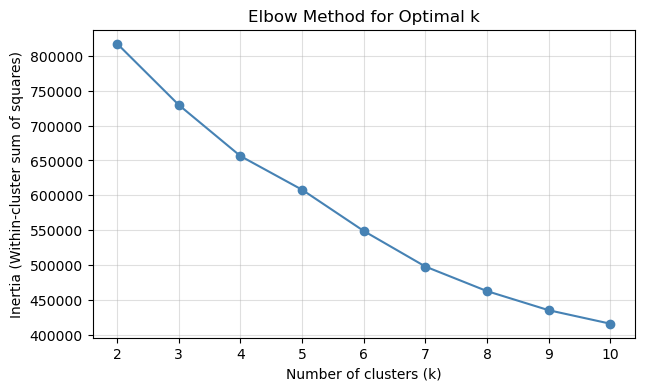

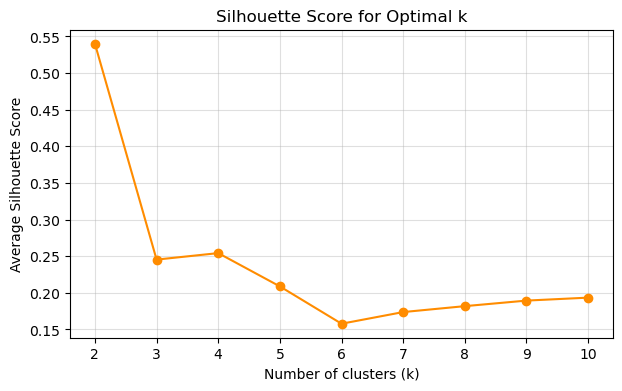

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

inertias = []
silhouette_scores = []
K = range(2, 11)  # test between 2 and 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    labels = kmeans.labels_
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

plt.figure(figsize=(7, 4))
plt.plot(K, inertias, 'o-', color='steelblue')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.grid(alpha=0.4)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(K, silhouette_scores, 'o-', color='darkorange')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.grid(alpha=0.4)
plt.show()

In [6]:
from sklearn.cluster import KMeans
optimal_k=4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)
df['cluster'] = cluster_labels

In [7]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
davies_bouldin_score(X, cluster_labels)

1.6721209849688308

In [8]:
calinski_harabasz_score(X, cluster_labels)

12685.600951089345

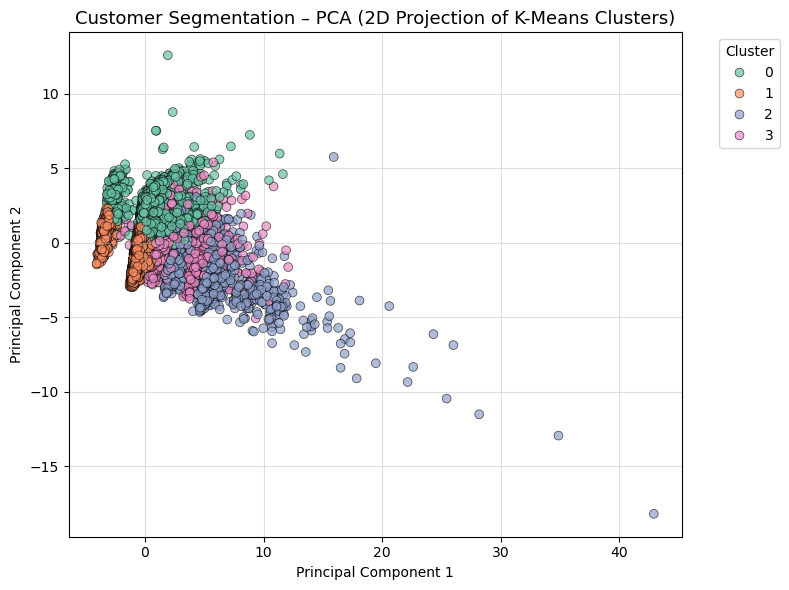

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
# Perform PCA to reduce to 2 components
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(cluster_df)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set2',
    s=40, alpha=0.7, edgecolor='k'
)

plt.title('Customer Segmentation – PCA (2D Projection of K-Means Clusters)', fontsize=13)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()


In [30]:
print(df['cluster'].value_counts().sort_index())
num_cols = [
    'num_orders',
    'total_spent',
    'avg_items_per_order',
    'avg_installments',
    'avg_review',
    'recency_days',
    'num_product_categories',
    'latitude','longitude'
]

cluster_summary = df.groupby('cluster')[num_cols].mean()
print(cluster_summary)

cat_cols = ['most_used_payment', 'most_bought_category','city','state']

cat_modes = (
    df.groupby('cluster')[cat_cols]
      .agg(lambda x: x.mode().iat[0] if not x.mode().empty else None)
)

cat_modes


cluster
0    20376
1    67314
2     2732
3     2936
Name: count, dtype: int64
         num_orders  total_spent  avg_items_per_order  avg_installments  \
cluster                                                                   
0          1.000049   244.967171             1.000000          5.618178   
1          1.000059    92.322698             1.000000          2.015723   
2          2.116764   240.424586             1.071605          3.265386   
3          1.021798   189.240010             2.161614          3.996253   

         avg_review  recency_days  num_product_categories   latitude  \
cluster                                                                
0          4.009170    285.329996                0.988025 -15.337594   
1          4.230009    270.164990                0.984743 -22.939843   
2          4.222781    253.581625                1.602489 -21.581392   
3          3.341069    275.133515                1.221390 -21.335970   

         longitude  
cluster          

,most_used_payment,most_bought_category,city,state
cluster,,,,
0,credit_card,health_beauty,sao paulo,SP
1,credit_card,bed_bath_table,sao paulo,SP
2,credit_card,bed_bath_table,sao paulo,SP
3,credit_card,bed_bath_table,sao paulo,SP


C:\Users\konin\AppData\Local\Temp\ipykernel_32536\1585043542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\konin\AppData\Local\Temp\ipykernel_32536\1585043542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\konin\AppData\Local\Temp\ipykernel_32536\1585043542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\konin\AppData\Local\Temp\ipykernel_32536\1585043542.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

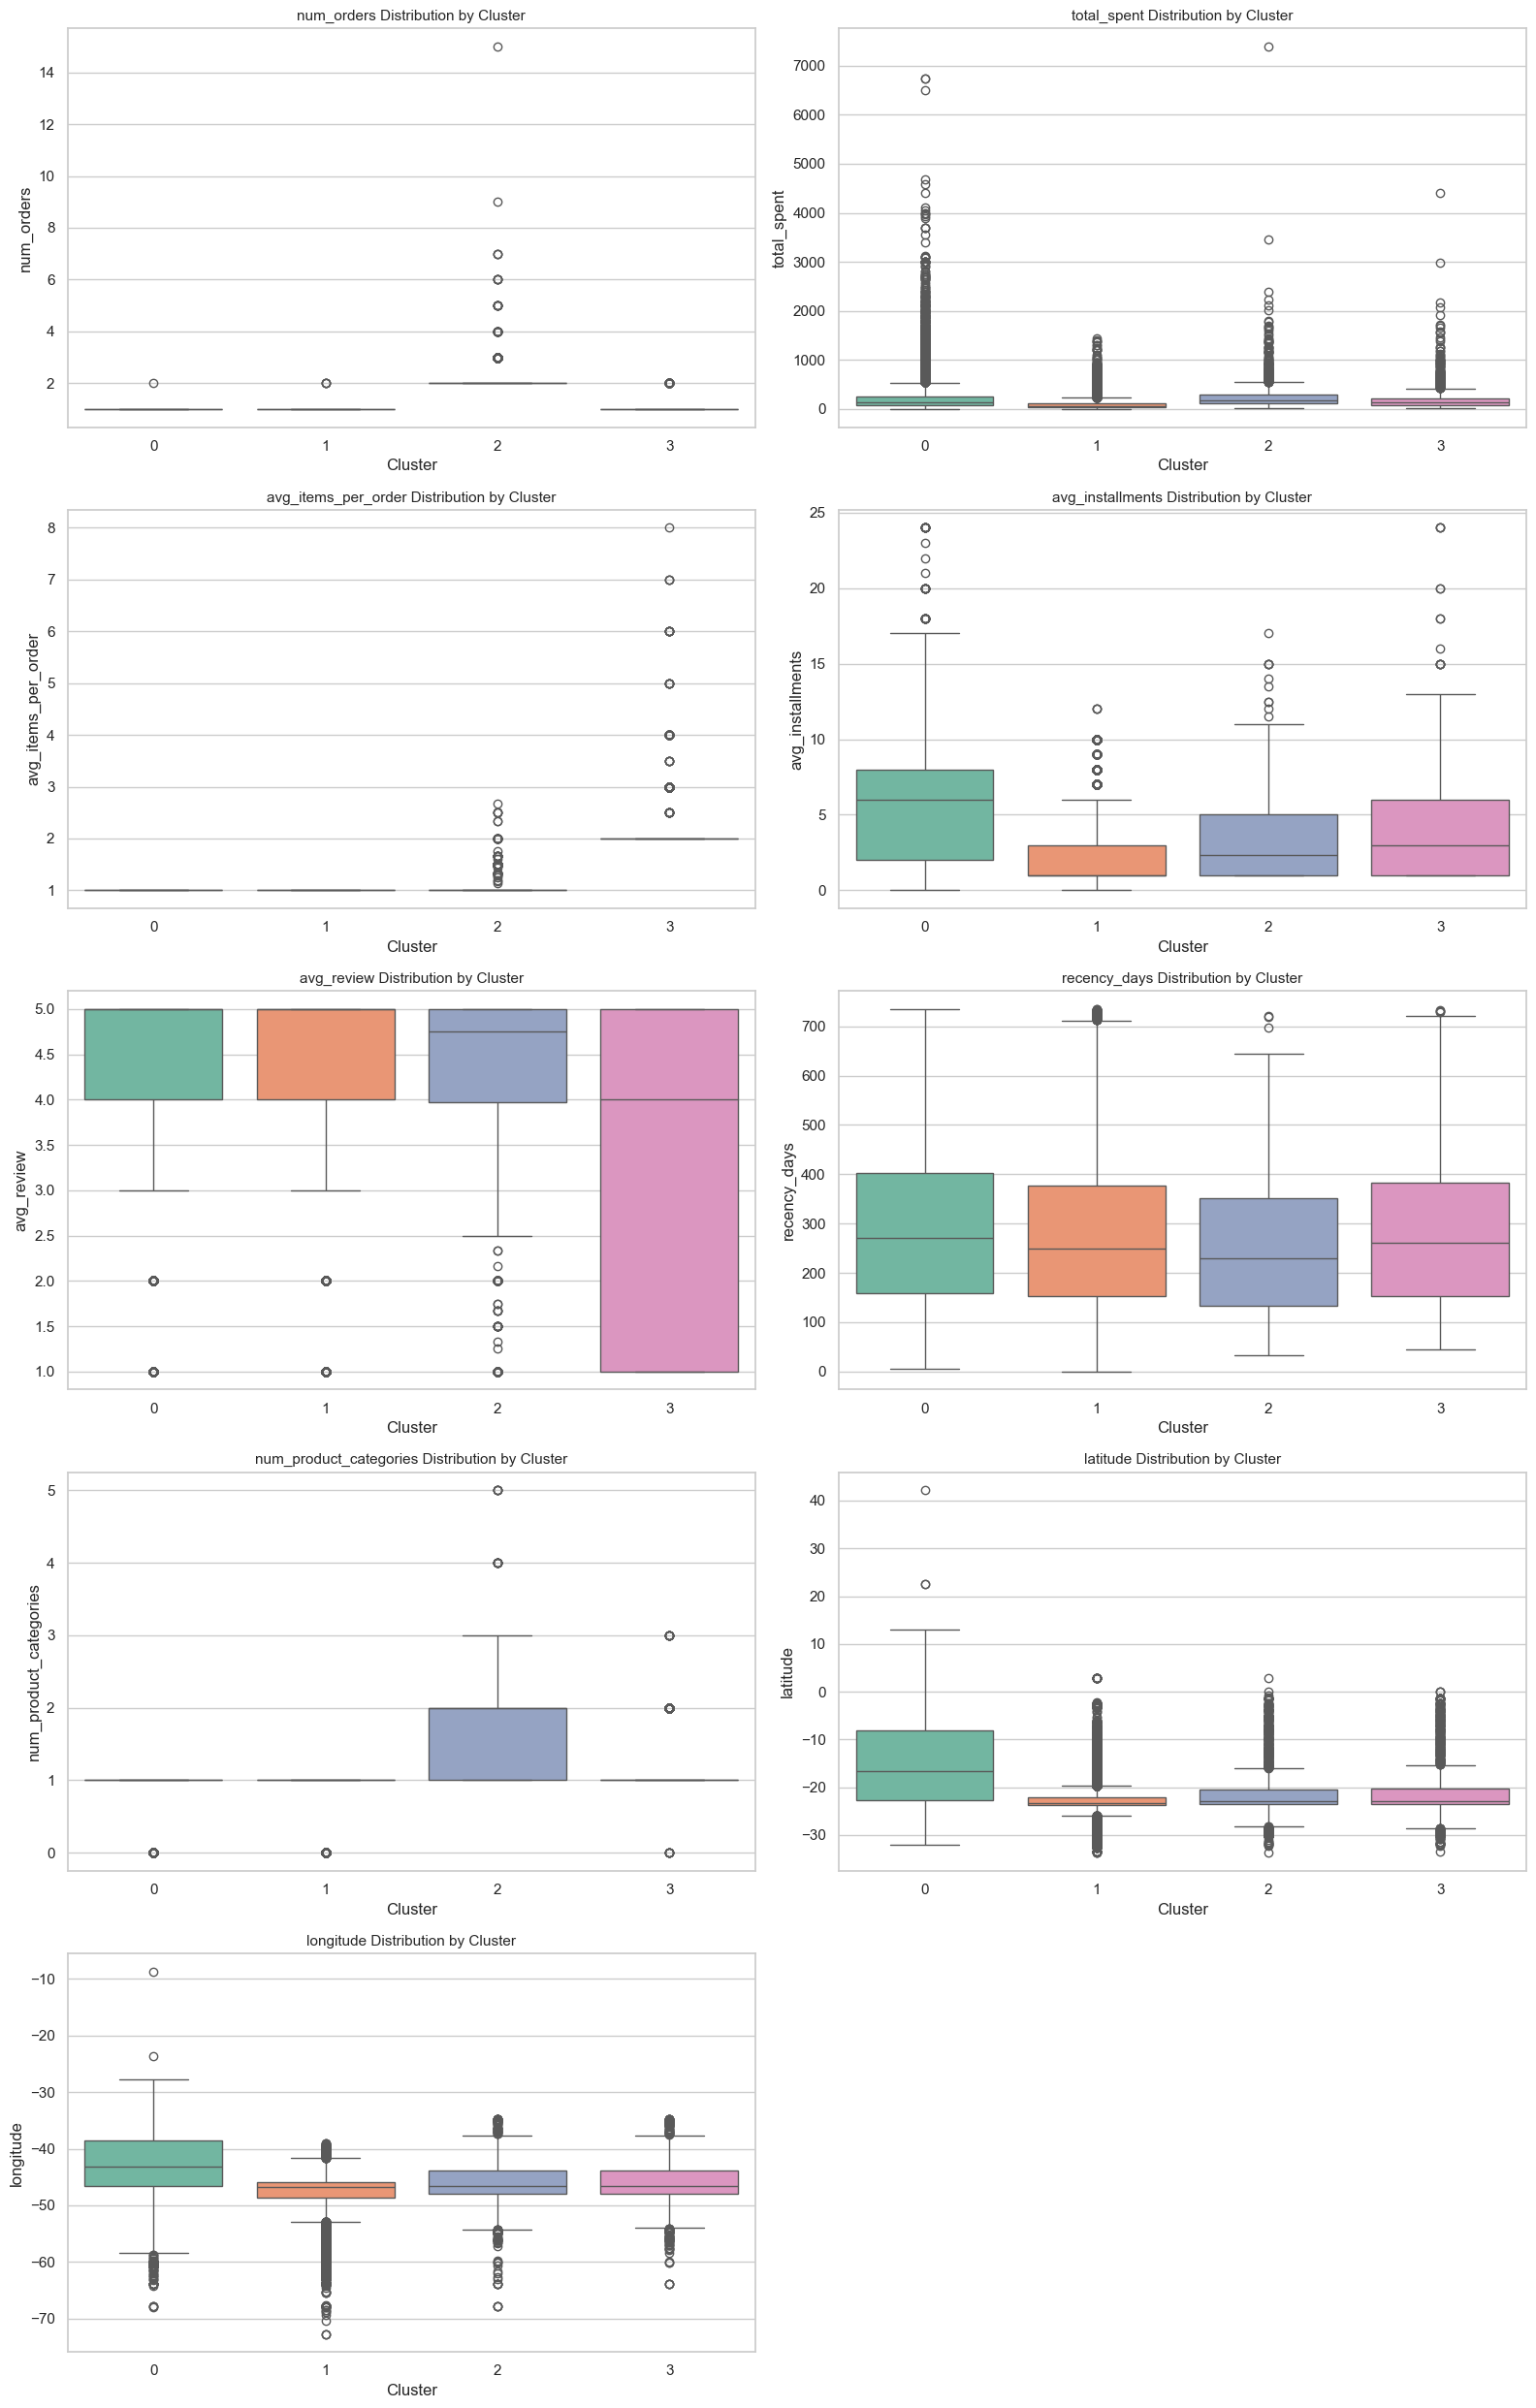

In [32]:
# Set plot style
sns.set(style="whitegrid", palette="Set2")

# Create boxplots for each numeric variable
plt.figure(figsize=(16, 25))  # Adjust for readability
for i, col in enumerate(num_cols, 1):
    plt.subplot(5, 2, i)
    sns.boxplot(
        data=df,
        x='cluster',
        y=col,
        palette='Set2'
    )
    plt.title(f'{col} Distribution by Cluster', fontsize=11)
    plt.xlabel('Cluster')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [9]:
import hdbscan
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import numpy as np
import matplotlib.pyplot as plt
pca = PCA(n_components=10, random_state=42)
X_reduced = pca.fit_transform(X)
clusterer = hdbscan.HDBSCAN(min_cluster_size=1000,  
                            min_samples=50,        # smaller -> more clusters
                            metric='euclidean',  
                            cluster_selection_epsilon=0.0,
                            cluster_selection_method='eom')

labels = clusterer.fit_predict(X_reduced)
df['h_cluster'] = labels
np.unique(labels, return_counts=True)

\\?\C:\Users\konin\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
\\?\C:\Users\konin\AppData\Roaming\jupyterlab-desktop\jlab_server\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(array([-1,  0,  1,  2,  3,  4]),
 array([  638,  1258,  1967,  1169,  1965, 86361]))

In [19]:
silhouette_score(X_reduced, labels)

0.4313843787716875

In [10]:
davies_bouldin_score(X_reduced, labels)

1.9882805943723971

In [11]:
calinski_harabasz_score(X_reduced, labels)

5877.9716081868455

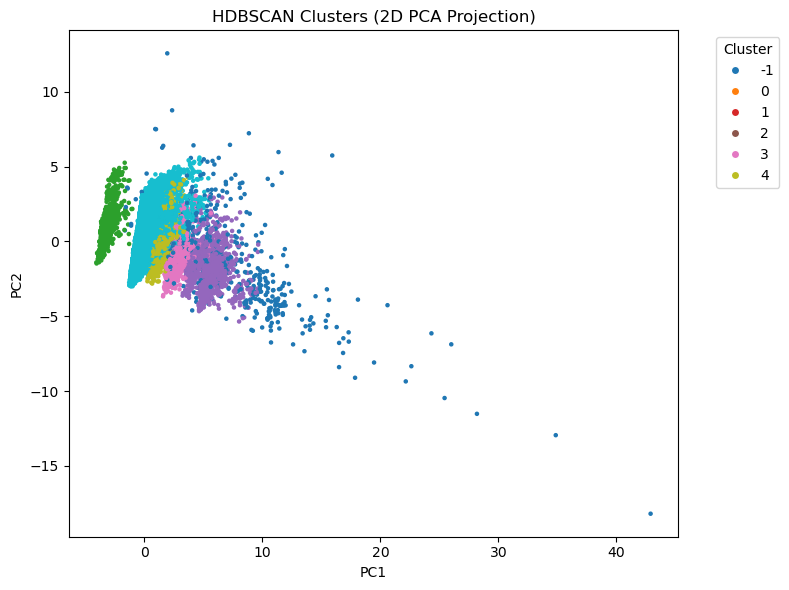

In [21]:

pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_reduced)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10', s=5)

# Create legend manually
unique_labels = np.unique(labels)
handles = [plt.Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.tab10(i / len(unique_labels)), markersize=6)
           for i in range(len(unique_labels))]
plt.legend(handles, [str(lbl) for lbl in unique_labels], title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("HDBSCAN Clusters (2D PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


In [23]:
num_cols = [
    'num_orders',
    'total_spent',
    'avg_items_per_order',
    'avg_installments',
    'avg_review',
    'recency_days',
    'num_product_categories',
    'latitude','longitude'
]
cluster_summary = df.groupby('h_cluster')[num_cols].mean()
print(cluster_summary)

cat_cols = ['most_used_payment', 'most_bought_category','city','state']

cat_modes = (
    df.groupby('h_cluster')[cat_cols]
      .agg(lambda x: x.mode().iat[0] if not x.mode().empty else None)
)

cat_modes

           num_orders  total_spent  avg_items_per_order  avg_installments  \
h_cluster                                                                   
-1           1.791536   668.903339             2.293822          4.691539   
 0           1.000795   103.851773             1.004769          2.509539   
 1           1.734621   213.201103             1.362820          3.659295   
 2           2.000000   203.532412             1.082121          3.040633   
 3           1.000000   161.433120             2.000000          3.792366   
 4           1.000000   126.059123             1.000000          2.853856   

           avg_review  recency_days  num_product_categories   latitude  \
h_cluster                                                                
-1           3.626018    268.094044                1.495298 -20.141620   
 0           4.061941    323.183625                0.000000 -21.337393   
 1           3.906332    241.862735                2.000000 -21.857245   
 2           

,most_used_payment,most_bought_category,city,state
h_cluster,,,,
-1,credit_card,bed_bath_table,sao paulo,SP
0,credit_card,bed_bath_table,sao paulo,SP
1,credit_card,bed_bath_table,sao paulo,SP
2,credit_card,bed_bath_table,sao paulo,SP
3,credit_card,bed_bath_table,sao paulo,SP
4,credit_card,health_beauty,sao paulo,SP


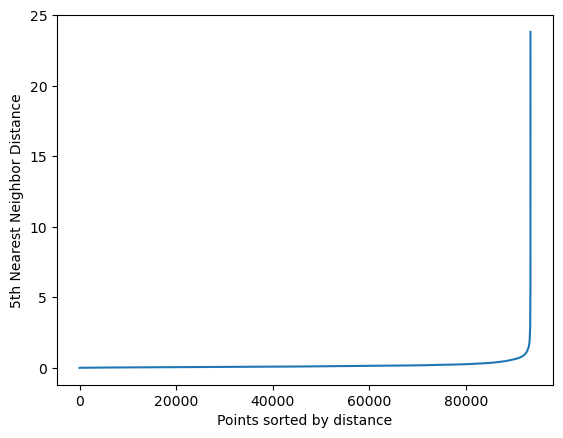

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import NearestNeighbors
pca = PCA(n_components=5, random_state=42)
X_reduced = pca.fit_transform(X)
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(X_reduced)
distances, indices = nbrs.kneighbors(X_reduced)
distances = np.sort(distances[:,4])
plt.plot(distances)
plt.ylabel("5th Nearest Neighbor Distance")
plt.xlabel("Points sorted by distance")
plt.show()

In [6]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=500).fit(X_reduced)
labels = dbscan.labels_
df['d_cluster'] = labels
np.unique(labels, return_counts=True)

(array([-1,  0,  1,  2,  3]), array([ 3643, 87346,   901,   966,   502]))

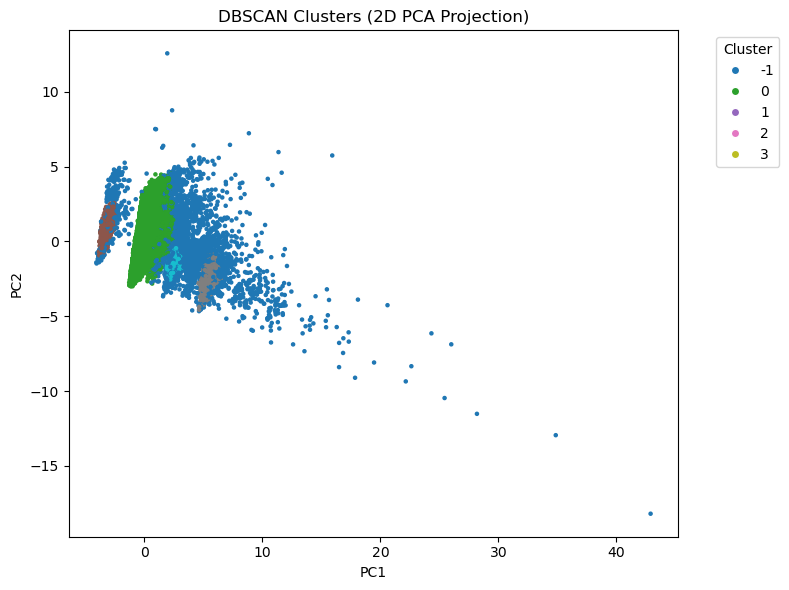

In [14]:
pca_vis = PCA(n_components=2, random_state=42)
X_vis = pca_vis.fit_transform(X_reduced)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_vis[:,0], X_vis[:,1], c=labels, cmap='tab10', s=5)

# Create legend manually
unique_labels = np.unique(labels)
handles = [plt.Line2D([], [], marker='o', color='w', markerfacecolor=plt.cm.tab10(i / len(unique_labels)), markersize=6)
           for i in range(len(unique_labels))]
plt.legend(handles, [str(lbl) for lbl in unique_labels], title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title("DBSCAN Clusters (2D PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score
silhouette_score(X_reduced, labels)

0.3391493330326439

In [8]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
davies_bouldin_score(X_reduced, labels)

1.5439154621018394

In [9]:
calinski_harabasz_score(X_reduced, labels)

5326.402943568112